Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Path to dataset files: /kaggle/input/eergy-efficiency-dataset

Dataset Shape: (768, 10)
Columns available: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2']

Training Gaussian Process Regression models (this might take a moment)...


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(



=== Evaluation Results ===
Heating Load (Y1) -> MSE: 0.2230, R² Score: 0.9979
Cooling Load (Y2) -> MSE: 1.7020, R² Score: 0.9816


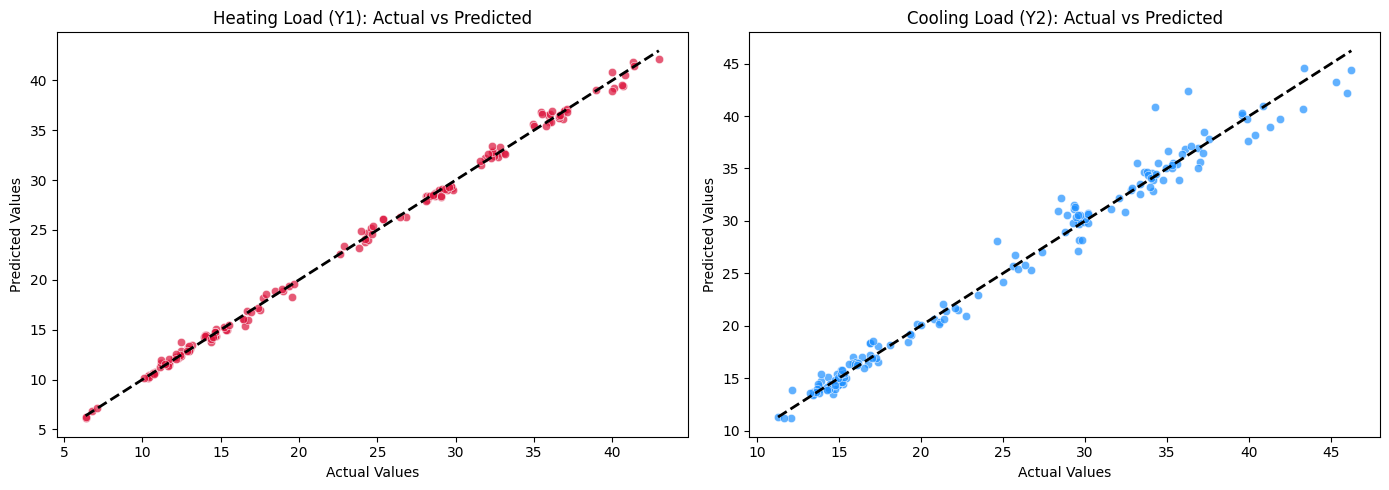

In [2]:
# =====================================================================
# PART 1: GAUSSIAN PROCESS REGRESSION (FIXED)
# =====================================================================

# 1. Install and Import necessary libraries
!pip install kagglehub scikit-learn pandas numpy matplotlib seaborn -q

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 2. Download and load the Energy Efficiency Dataset
kagglepath = "elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)
print("Path to dataset files:", path)

# Find and load the CSV
csv_file = os.path.join(path, "ENB2012_data.csv")
df = pd.read_csv(csv_file)

# Clean dataset: Drop any completely empty columns/rows if they exist
df = df.dropna(how='all')
df = df.dropna(axis=1, how='all')

print("\nDataset Shape:", df.shape)
print("Columns available:", df.columns.tolist())

# Map columns based on UCI / Kaggle specification:
if 'X1' not in df.columns:
    df.columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2']

# 3. Data Preprocessing
X = df[['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']]
Y = df[['Y1', 'Y2']]

# --- FIXED THE TYPO HERE: Changed test_test_split to test_size ---
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Scale features (Crucial for Gaussian Processes due to distance metrics)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Scale targets
scaler_Y = StandardScaler()
Y_train_scaled = scaler_Y.fit_transform(Y_train)
Y_test_scaled = scaler_Y.transform(Y_test)

# 4. Define and Train the Gaussian Process Model
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1e-1)

# MultiOutputRegressor allows us to model both Y1 and Y2 simultaneously using GPR
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
multi_gpr = MultiOutputRegressor(gpr)

print("\nTraining Gaussian Process Regression models (this might take a moment)...")
multi_gpr.fit(X_train_scaled, Y_train_scaled)

# 5. Predictions and Evaluation
Y_pred_scaled = multi_gpr.predict(X_test_scaled)

# Inverse transform back to original scale
Y_pred = scaler_Y.inverse_transform(Y_pred_scaled)

# Calculate metrics for Heating Load (Y1)
mse_y1 = mean_squared_error(Y_test['Y1'], Y_pred[:, 0])
r2_y1 = r2_score(Y_test['Y1'], Y_pred[:, 0])

# Calculate metrics for Cooling Load (Y2)
mse_y2 = mean_squared_error(Y_test['Y2'], Y_pred[:, 1])
r2_y2 = r2_score(Y_test['Y2'], Y_pred[:, 1])

print("\n=== Evaluation Results ===")
print(f"Heating Load (Y1) -> MSE: {mse_y1:.4f}, R² Score: {r2_y1:.4f}")
print(f"Cooling Load (Y2) -> MSE: {mse_y2:.4f}, R² Score: {r2_y2:.4f}")

# 6. Visualization
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=Y_test['Y1'], y=Y_pred[:, 0], alpha=0.7, color='crimson')
plt.plot([Y_test['Y1'].min(), Y_test['Y1'].max()], [Y_test['Y1'].min(), Y_test['Y1'].max()], 'k--', lw=2)
plt.title('Heating Load (Y1): Actual vs Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

plt.subplot(1, 2, 2)
sns.scatterplot(x=Y_test['Y2'], y=Y_pred[:, 1], alpha=0.7, color='dodgerblue')
plt.plot([Y_test['Y2'].min(), Y_test['Y2'].max()], [Y_test['Y2'].min(), Y_test['Y2'].max()], 'k--', lw=2)
plt.title('Cooling Load (Y2): Actual vs Predicted')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

plt.tight_layout()
plt.show()

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Path to dataset files: /kaggle/input/green-building-multi-source-environment-dataset

Dataset Shape: (2400, 19)

First 5 rows of data:
   indoor_temperature  indoor_humidity  co2_concentration  indoor_lighting  \
0           22.494481        43.624167         554.345944       432.115959   
1           29.408572        32.868476         466.383802       221.965186   
2           26.783927        46.385156        1850.558681       566.559664   
3           25.183902        42.448700         663.712464       201.348306   
4           19.872224        57.084826        1705.062755       940.588677   

   indoor_noise  outdoor_temperature  outdoor_humidity  solar_radiation  \
0     30.958646            24.443784         22.670752       540.768233   
1     68.624892            -1.398534         50.087239       699.959413   
2     38.547245             5.904842         24.415262       828.1085

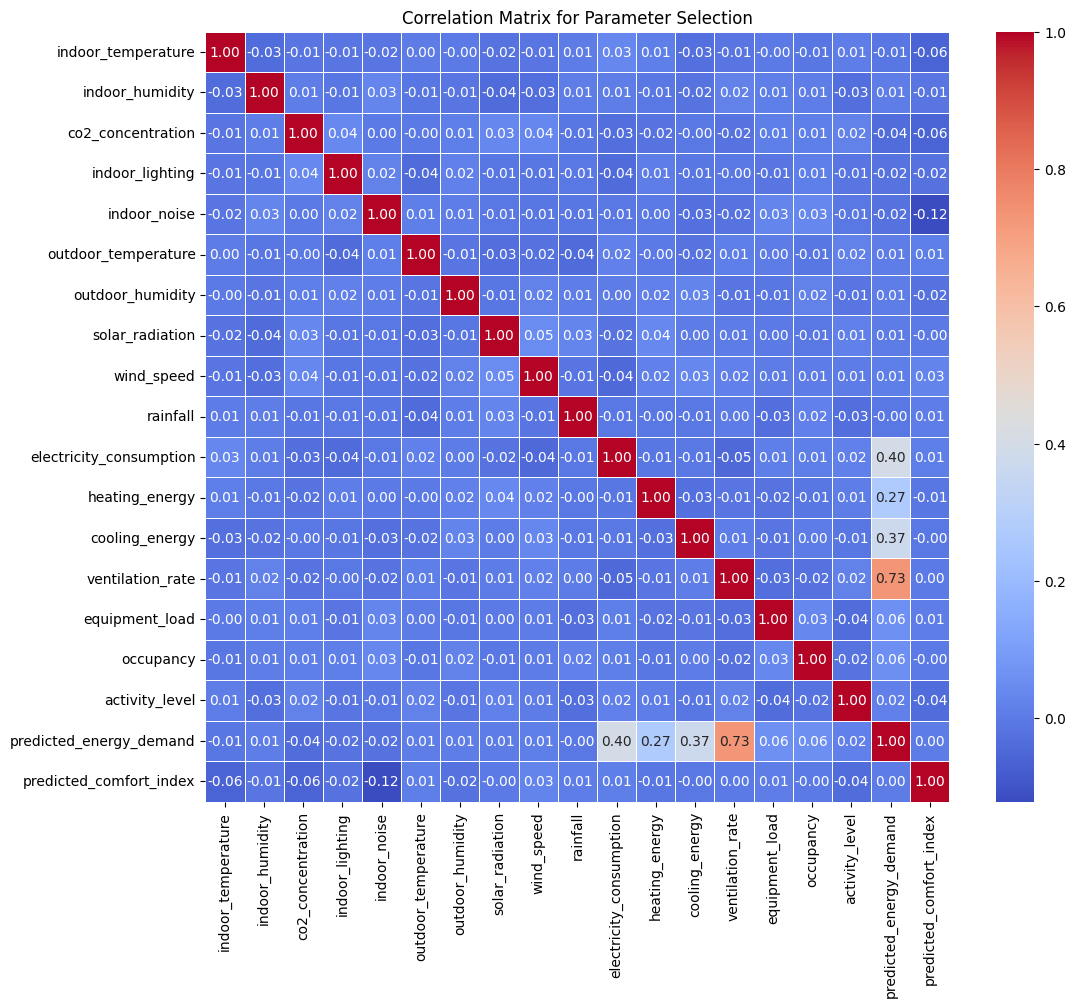


Target Variable identified: predicted_energy_demand

Selected Features for Linear Regression:
['indoor_temperature', 'indoor_humidity', 'co2_concentration', 'indoor_lighting', 'indoor_noise', 'outdoor_temperature', 'outdoor_humidity', 'solar_radiation', 'wind_speed', 'rainfall', 'electricity_consumption', 'heating_energy', 'cooling_energy', 'ventilation_rate', 'equipment_load', 'occupancy', 'activity_level', 'predicted_comfort_index']

=== Linear Regression Results ===
Mean Absolute Error (MAE): 1.5108
Root Mean Squared Error (RMSE): 1.9134
R² Score (Variance Explained): 0.9608

Feature Importances (Model Coefficients):
                Feature  Coefficient
predicted_comfort_index     3.527495
electricity_consumption     0.293108
         cooling_energy     0.249983
         heating_energy     0.248961
         equipment_load     0.095677
       ventilation_rate     0.050006
              occupancy     0.045624
         activity_level     0.032116
             wind_speed     0.007837
 

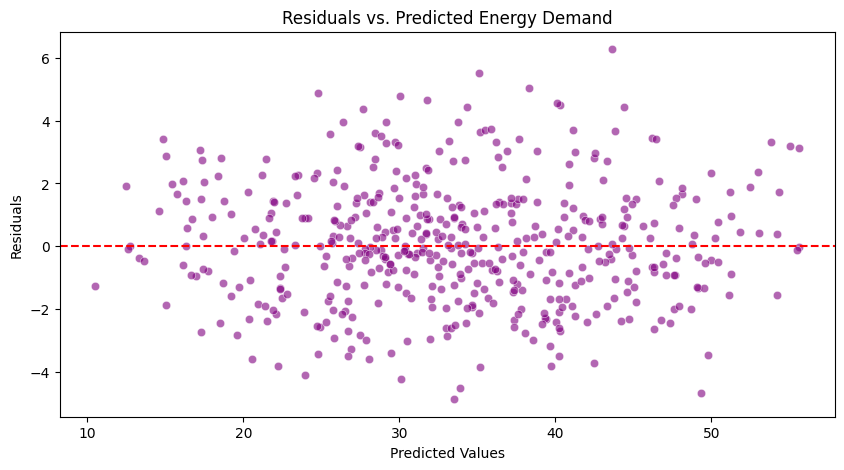

In [4]:
# =====================================================================
# PART 2: LINEAR REGRESSION (FIXED)
# =====================================================================

# 1. Install and Import necessary libraries
!pip install kagglehub scikit-learn pandas numpy matplotlib seaborn -q

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 2. Download and load the Green Building Dataset
kagglepath = "programmer3/green-building-multi-source-environment-dataset"
path = kagglehub.dataset_download(kagglepath)
print("Path to dataset files:", path)

# Load the dataset CSV
csv_file = os.path.join(path, "green_building_dataset.csv")
df2 = pd.read_csv(csv_file)

print("\nDataset Shape:", df2.shape)
print("\nFirst 5 rows of data:")
print(df2.head())

# 3. Parameter Selection Justification (Correlation Analysis)
# Filter out non-numeric columns for correlation calculation if they exist
numeric_df = df2.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix for Parameter Selection")
plt.show()

# Identify target variable column name
target_col = 'predicted_energy_demand'

if target_col not in df2.columns:
    # Fallback check in case capitalization varies
    target_col = [col for col in df2.columns if 'energy_demand' in col.lower()][0]

print(f"\nTarget Variable identified: {target_col}")

# --- FIXED THE ERROR HERE: Properly handling lowercase column check ---
X2 = numeric_df.drop(columns=[target_col])

# Check if any column name, when lowercased, matches 'id'
lowercased_columns = [col.lower() for col in X2.columns]
if 'id' in lowercased_columns:
    # Find the exact original column name that matched 'id'
    id_col = [col for col in X2.columns if col.lower() == 'id'][0]
    X2 = X2.drop(columns=[id_col])

y2 = numeric_df[target_col]

print("\nSelected Features for Linear Regression:")
print(X2.columns.tolist())

# 4. Model Training
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train2, y_train2)

# 5. Evaluation
y_pred2 = lr_model.predict(X_test2)

mse2 = mean_squared_error(y_test2, y_pred2)
rmse2 = np.sqrt(mse2)
mae2 = mean_absolute_error(y_test2, y_pred2)
r2_2 = r2_score(y_test2, y_pred2)

print("\n=== Linear Regression Results ===")
print(f"Mean Absolute Error (MAE): {mae2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse2:.4f}")
print(f"R² Score (Variance Explained): {r2_2:.4f}")

# Display Model Coefficients (Justification of impact per parameter)
coefficients = pd.DataFrame({
    'Feature': X2.columns,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\nFeature Importances (Model Coefficients):")
print(coefficients.to_string(index=False))

# 6. Residual Plot to verify Linear Assumptions
residuals = y_test2 - y_pred2
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_pred2, y=residuals, alpha=0.6, color='purple')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Energy Demand')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()